## Heart Disease Dataset - Bivariate Analysis

Objective: Finding relations between different parameters, especially the relation with "Heart Disease Diagnosed" to understand what are the major factors behind heart diseases.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv(r"clean_heart_data.csv")

In [25]:
df.head()

,patient_id,age,gender,chest_pain_type,resting_bp_mmhg,cholesterol_mg/dl,max_heart_rate,st_depression,exercise_induced_angina,heart_disease
0,1,87,1,-1,151.343081,162.378238,162.287641,2.801430,-1,0
1,2,66,1,-1,101.214098,218.380992,155.846201,0.182318,-1,0
2,3,87,0,1,150.354093,248.765623,195.335192,0.875113,1,1
3,5,45,1,0,112.437303,211.572296,121.968906,0.982994,-1,1
4,7,89,0,3,130.057209,252.086233,164.887272,1.889154,-1,1


Text(0.5, 0, 'Heart Disease(1=found 0=not found)')

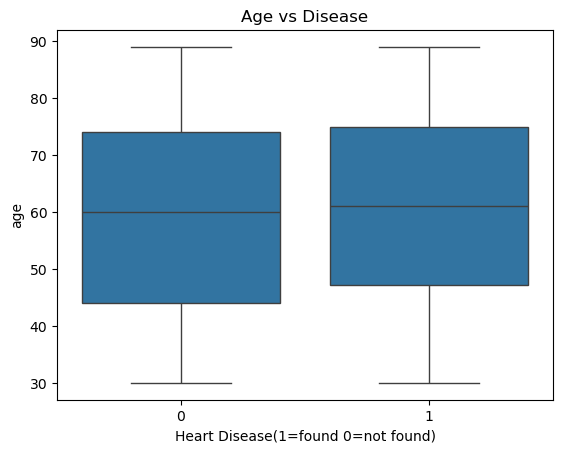

In [26]:
sns.boxplot(data=df,y='age',x='heart_disease')
plt.title('Age vs Disease')
plt.xlabel('Heart Disease(1=found 0=not found)')

In [27]:
df['heart_disease'].value_counts()

heart_disease
1    402
0    380
Name: count, dtype: int64

402 heart disease diagnosed patients found with age range 50-75 whereas 380 "no disease" cases with similar age group. This concludes that age doesn't strongly define whether a patient has heart disease or not i.e. age has no clear effect.

Text(0.5, 0, 'Sex(1=Male 0=Female)')

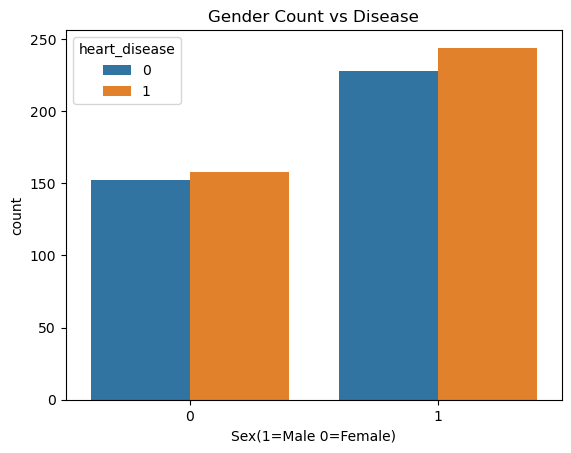

In [28]:
sns.countplot(data=df,hue='heart_disease',x='gender')
plt.title('Gender Count vs Disease')
plt.xlabel('Sex(1=Male 0=Female)')

There are around 300 cases for females, which are almost equally distributed to disease and no disease cases. Same goes for male 500 cases. Though there is almost the same disease/no disease ratio for each gender, the male count is noticeably higher than the female count, meaning males are more susceptible to heart diseases.

Text(0.5, 0, 'Chest Pain Type')

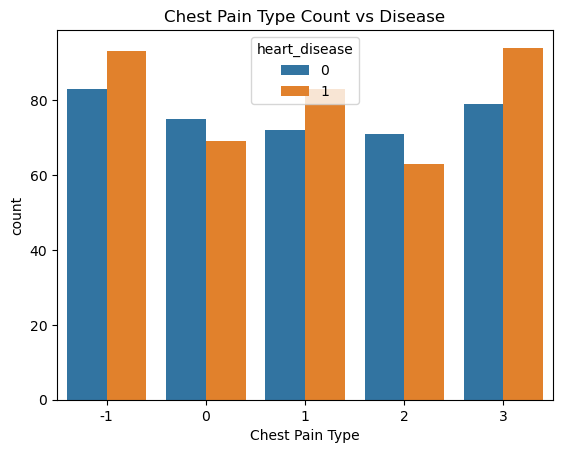

In [29]:
sns.countplot(data=df,hue='heart_disease',x='chest_pain_type')
plt.title('Chest Pain Type Count vs Disease')
plt.xlabel('Chest Pain Type')

#### N.B. -1=Unknown, 0=Typical Angina, 1=Atypical Angina
#### 2=Non-anginal pain, 3=Asymtomatic

In [30]:
pd.crosstab(df['chest_pain_type'], df['heart_disease'])

heart_disease,0,1
chest_pain_type,,
-1,83,93
0,75,69
1,72,83
2,71,63
3,79,94


1. It looks like all cases come up with close number of disease and no disease findings
2. 75+69 cases for Typical Angina(Most Dangerous). However, it is not a strong indicator of heart disease as people with this type of angina are still diagnosed as healthy at same frequency.
3. The "Asymptomatic(No pain but actually silent)" case count is higher than other types which is interesting. Also, their disease cases(94) is substantially higher than non-disease(79) cases. This refers that patient with Type-3 chest pain have a higher chance for heart diseases.

Text(0.5, 0, '1=Disease, 0=No disease')

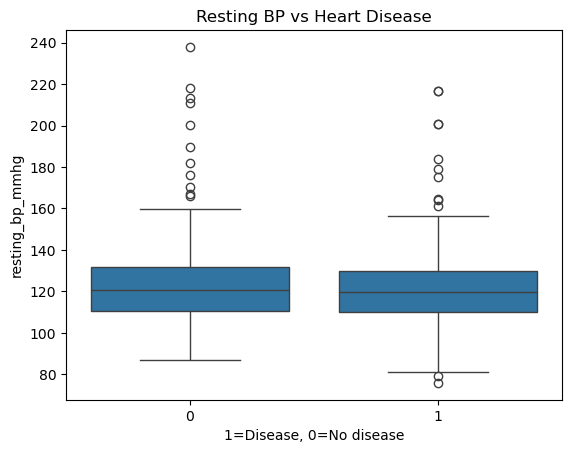

In [31]:
sns.boxplot(data=df,x='heart_disease',y='resting_bp_mmhg')
plt.title('Resting BP vs Heart Disease')
plt.xlabel('1=Disease, 0=No disease')

* Most of the patients bear a resting blood pressure 110-130 mmhg. However, "no disease cases" also have almost the same range of blood pressue value. Aside, possible outlying values(>160) are also common for both the types.
* This points out that blood pressure range is not a strong indicator to heart diseases.

Text(0.5, 0, '0=No Disease, 1=Disease')

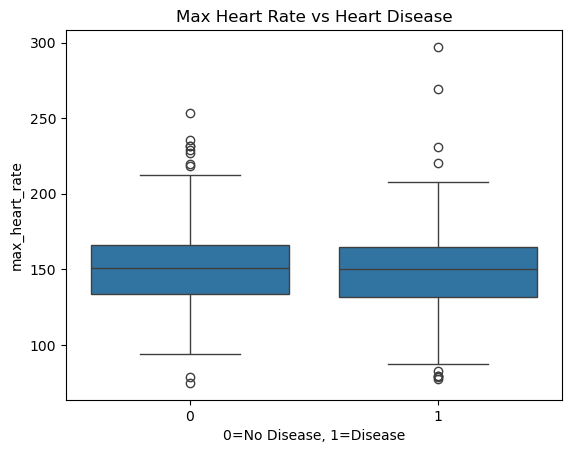

In [36]:
sns.boxplot(data=df,x='heart_disease',y='max_heart_rate')
plt.title('Max Heart Rate vs Heart Disease')
plt.xlabel('0=No Disease, 1=Disease')

In [34]:
df['heart_disease'].value_counts()

heart_disease
1    402
0    380
Name: count, dtype: int64

* For both cases, the range of heart rate is almost the same.
* Few outliers are also seen, however, again for both of the cases.
* Heart rate is not a strong factor in determining heart diseases.

Text(0.5, 1.0, 'Correlation Heatmap')

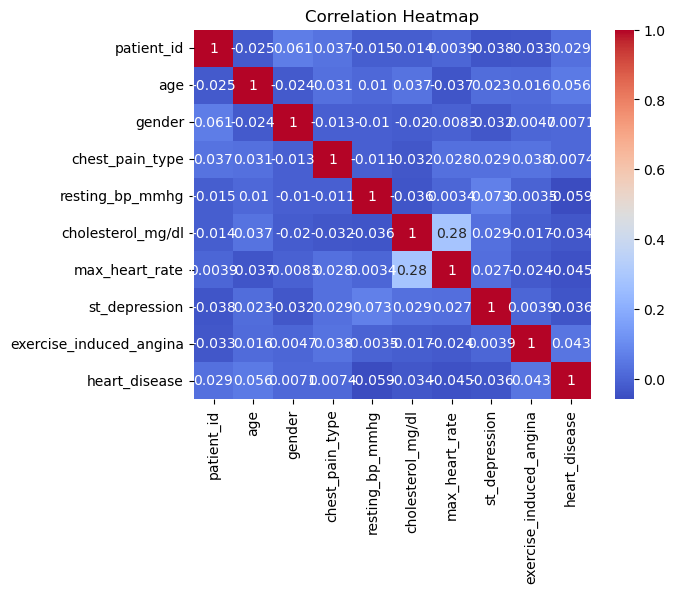

In [41]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')

* It looks like parameters have very little relation with each other as maximum of the cells are in the 0 - 0.2 range.
* Only Cholesterol level vs Max Heart Rate correlates by 0.28, meaning as the Cholesterol Level increases, the Heart Rate may also increase.
* No other factor shows a strong correlation with others.

Text(0, 0.5, 'Resting Blood Pressure')

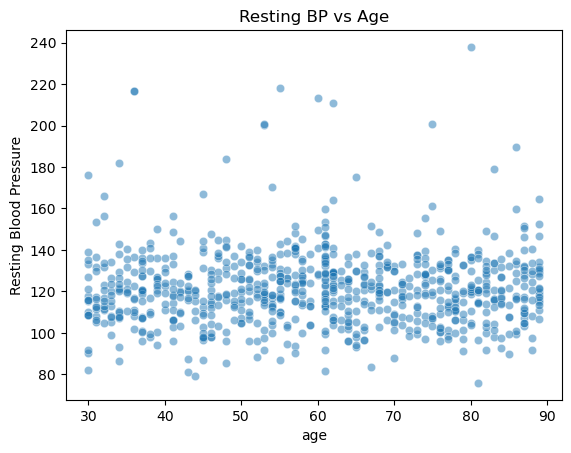

In [46]:
sns.scatterplot(data=df,x='age',y='resting_bp_mmhg',alpha=0.5)
plt.title('Resting BP vs Age')
plt.ylabel('Resting Blood Pressure')

* No matter which age group, it contains almost same range of blood pressure ranges.
* So Low or High BP may be seen at any age of patients.

Text(0, 0.5, 'Max HR')

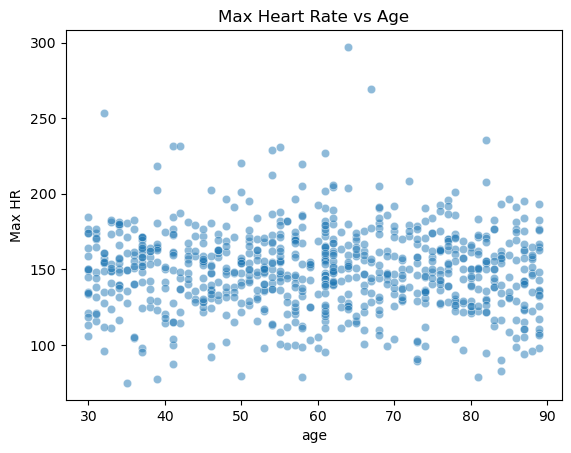

In [47]:
sns.scatterplot(data=df,x='age',y='max_heart_rate',alpha=0.5)
plt.title('Max Heart Rate vs Age')
plt.ylabel('Max HR')

* Similar to BP, heart rates are almost varying for all different age groups.
* No specifiq age group bear a higher/lower HR.

Text(0.5, 0, 'Cholesterol Level')

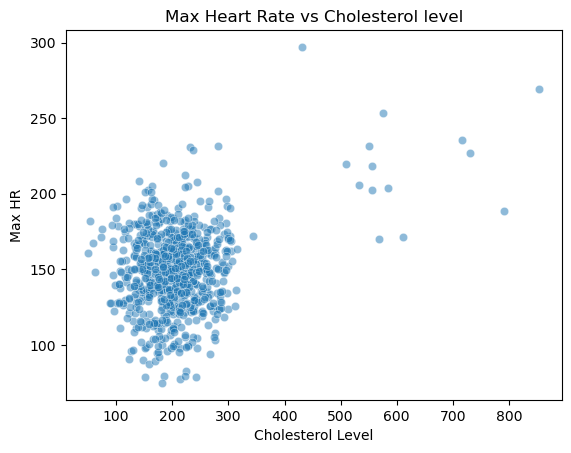

In [49]:
sns.scatterplot(data=df,x='cholesterol_mg/dl',y='max_heart_rate',alpha=0.5)
plt.title('Max Heart Rate vs Cholesterol level')
plt.ylabel('Max HR')
plt.xlabel('Cholesterol Level')

* For average cholesterol level (around 200) the HR varies from 50-200.
* For cholesterol level less than average(around 100) the HR is basically at higher range(125-200). Doctors may identify it.
* For cholesterol level more than average(around 300) the HR is also at high range(125-200).
* Many Outliers are seen (like unexpectedly high cholesterol value) as well as HR.

## Key Insights:

1. Patients from a vast range of age groups are susceptible to heart diseases.
2. Men are more vulnerable to heart disease than women.
3. Chest pain type 3 patients are more likely to have heart diseases than other chest pain types.
4. HR/BP alone are not strong indicators of heart disease.
5. Heart parameters are very discrete, i.e., they are very unlikely to depend on each other as per this particular dataset.

## Summary

We have got some important insights regarding which parameters indicate heart disease and which do not indicate heart disease by analyzing this dataset. These are valuable for identification. We will analyze further, combining more than 2 parameters, altogether, to develop a highly accurate and realistic identification approach to heart diseases.